# ABP T–D sweep diagnostics

This notebook compares integration times `T = 10, 20, 40` and noise values `D = 0.5, 0.1, 0.05` from the Slurm array job.

It expects the array job layout produced by `run_abp_TD_sweep_array_nariman.sh`:

```text
ABPNoiseSweep/data/abp_TD_sweep_<JOB_ID>/
  task_0_T10_D0p5/data/abp_endpoint_conditioned_D0p5/
  ...
  combined/data/abp_endpoint_conditioned_T10_D0p5/
  ...
```


In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Optional display helper
try:
    from IPython.display import display
except Exception:
    display = print


## 1. Select the run folder

Set `ARRAY_JOB_ID` to the Slurm array job ID. Leave it as `None` to automatically select the newest `abp_TD_sweep_*` folder.

In [10]:
ARRAY_JOB_ID = 1370499 # e.g. 1280123, or None for newest

RUNS_ROOT = Path(
    "/home/nst/amarin/Desktop/ABP_Rare_Events/"
    "ABPNoiseSweep/data"
)

if ARRAY_JOB_ID is None:
    candidates = sorted(
        [p for p in RUNS_ROOT.glob("abp_TD_sweep_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No abp_TD_sweep_* folders found in {RUNS_ROOT}")
    ARRAY_RUN_DIR = candidates[0]
else:
    ARRAY_RUN_DIR = RUNS_ROOT / f"abp_TD_sweep_{ARRAY_JOB_ID}"

RUN_DIR = ARRAY_RUN_DIR
PLOTS_DIR = RUN_DIR / "plots"

SAVE_FIGS = True
SHOW_FIGS = True
FIG_DPI = 180

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ARRAY_RUN_DIR = {ARRAY_RUN_DIR.resolve()}")
print(f"PLOTS_DIR     = {PLOTS_DIR.resolve()}")
print(f"Run exists?   {ARRAY_RUN_DIR.exists()}")


ARRAY_RUN_DIR = /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499
PLOTS_DIR     = /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/plots
Run exists?   True


## 2. Helper functions

In [11]:
FIGURES = []


def read_csv_if_exists(path, **kwargs):
    path = Path(path)
    if not path.exists():
        print(f"Missing, skipped: {path}")
        return None
    return pd.read_csv(path, **kwargs)


def read_key_value_csv(path):
    df = read_csv_if_exists(path)
    if df is None or df.empty or not {"key", "value"}.issubset(df.columns):
        return {}
    out = {}
    for _, row in df.iterrows():
        key = str(row["key"])
        value = row["value"]
        numeric_value = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
        if pd.notna(numeric_value):
            out[key] = numeric_value
        else:
            value_str = str(value)
            if value_str.lower() == "true":
                out[key] = True
            elif value_str.lower() == "false":
                out[key] = False
            else:
                out[key] = value
    return out


def safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")


def save_and_maybe_show(fig, filename):
    path = PLOTS_DIR / filename
    if SAVE_FIGS:
        fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
        FIGURES.append(path)
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)
    return path


def restrict_range(df, col, value_range):
    if value_range is None:
        return df
    lo, hi = value_range
    work = df.copy()
    work[col] = pd.to_numeric(work[col], errors="coerce")
    if lo is not None:
        work = work[work[col] >= lo]
    if hi is not None:
        work = work[work[col] <= hi]
    return work


def parse_T_D_from_path(path):
    text = str(path)
    T = np.nan
    D = np.nan

    mT = re.search(r"T([0-9]+(?:p[0-9]+)?)", text)
    if mT:
        try:
            T = float(mT.group(1).replace("p", "."))
        except Exception:
            pass

    mD = re.search(r"D([0-9]+(?:p[0-9]+)?)", text)
    if mD:
        try:
            D = float(mD.group(1).replace("p", "."))
        except Exception:
            pass

    return T, D


def case_metadata(case_dir):
    summary = read_key_value_csv(case_dir / "case_summary.csv")
    T = pd.to_numeric(pd.Series([summary.get("trajectory_T", np.nan)]), errors="coerce").iloc[0]
    D = pd.to_numeric(pd.Series([summary.get("D", np.nan)]), errors="coerce").iloc[0]

    T_path, D_path = parse_T_D_from_path(case_dir)
    if not np.isfinite(T):
        T = T_path
    if not np.isfinite(D):
        D = D_path

    return summary, float(T) if np.isfinite(T) else np.nan, float(D) if np.isfinite(D) else np.nan


def label_for_case(case_dir):
    _, T, D = case_metadata(case_dir)
    if np.isfinite(T) and np.isfinite(D):
        return f"T={T:g}, D={D:g}"
    return case_dir.name


def case_tag(case_dir):
    _, T, D = case_metadata(case_dir)
    if np.isfinite(T) and np.isfinite(D):
        return safe_name(f"T{T:g}_D{D:g}")
    return safe_name(case_dir.name)


def find_case_dirs(array_run_dir=ARRAY_RUN_DIR):
    """
    Find completed T-D cases. Prefer original task outputs over combined copies.
    Deduplicate by (T, D).
    """
    array_run_dir = Path(array_run_dir)
    found = {}

    # Original task outputs.
    for case_dir in sorted(array_run_dir.glob("task_*/data/abp_endpoint_conditioned_*")):
        if not case_dir.is_dir() or not (case_dir / "case_summary.csv").exists():
            continue
        _, T, D = case_metadata(case_dir)
        key = (round(T, 12), round(D, 12)) if np.isfinite(T) and np.isfinite(D) else (case_dir.name, str(case_dir))
        found[key] = case_dir

    # Combined copies, useful if task dirs were moved or if you want one clean tree.
    for case_dir in sorted((array_run_dir / "combined" / "data").glob("abp_endpoint_conditioned_*")):
        if not case_dir.is_dir() or not (case_dir / "case_summary.csv").exists():
            continue
        _, T, D = case_metadata(case_dir)
        key = (round(T, 12), round(D, 12)) if np.isfinite(T) and np.isfinite(D) else (case_dir.name, str(case_dir))
        found.setdefault(key, case_dir)

    def sort_key(p):
        _, T, D = case_metadata(p)
        return (np.inf if not np.isfinite(T) else T, np.inf if not np.isfinite(D) else D)

    return sorted(found.values(), key=sort_key)


case_dirs = find_case_dirs()
print(f"Found {len(case_dirs)} completed T-D case(s):")
for p in case_dirs:
    print("  ", label_for_case(p), "->", p)


Found 9 completed T-D case(s):
   T=10, D=0.05 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_2_T10_D0p05/data/abp_endpoint_conditioned_D0p05
   T=10, D=0.1 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_1_T10_D0p1/data/abp_endpoint_conditioned_D0p1
   T=10, D=0.5 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_0_T10_D0p5/data/abp_endpoint_conditioned_D0p5
   T=20, D=0.05 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_5_T20_D0p05/data/abp_endpoint_conditioned_D0p05
   T=20, D=0.1 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_4_T20_D0p1/data/abp_endpoint_conditioned_D0p1
   T=20, D=0.5 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABPNoiseSweep/data/abp_TD_sweep_1370499/task_3_T20_D0p5/data/abp_endpoint_conditioned_D0p5
   T=40, D=0.05 -> /home/nst/amarin/Desktop/ABP_Rare_Events/ABP

## 3. Summary and completeness check

## 4. Endpoint probabilities versus integration time

These are the main “transition by time `T`” diagnostics. They are computed from the full reweighted endpoint histogram `hist_endpoint_x_T.csv`, not from saved trajectories.

,T,D,condition,probability
1,10.0,0.05,x_gt0,0.000007
10,20.0,0.05,x_gt0,0.000013
19,40.0,0.05,x_gt0,0.000022
4,10.0,0.10,x_gt0,0.008314
13,20.0,0.10,x_gt0,0.018443
22,40.0,0.10,x_gt0,0.037406
7,10.0,0.50,x_gt0,0.479701
16,20.0,0.50,x_gt0,0.489699
25,40.0,0.50,x_gt0,0.492918
2,10.0,0.05,x_gt_0p5,0.000006


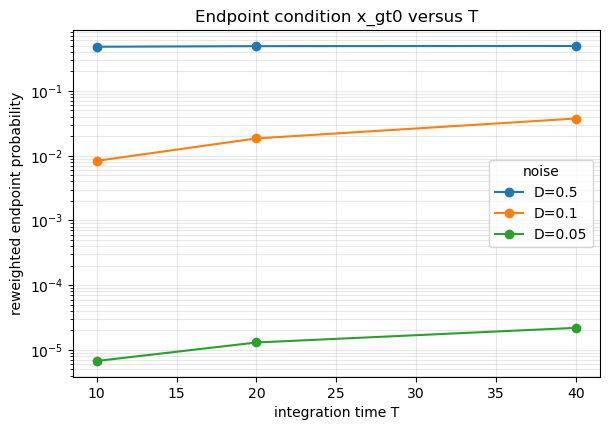

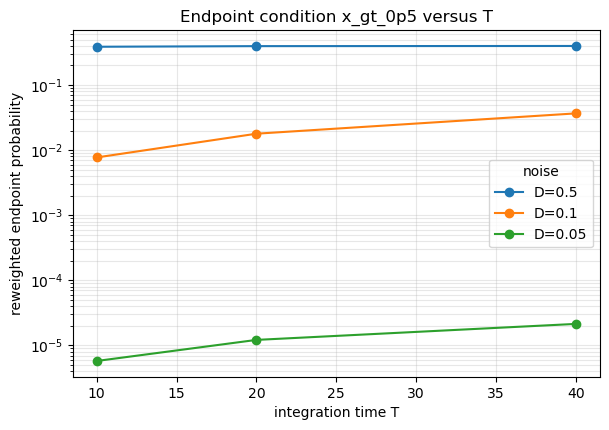

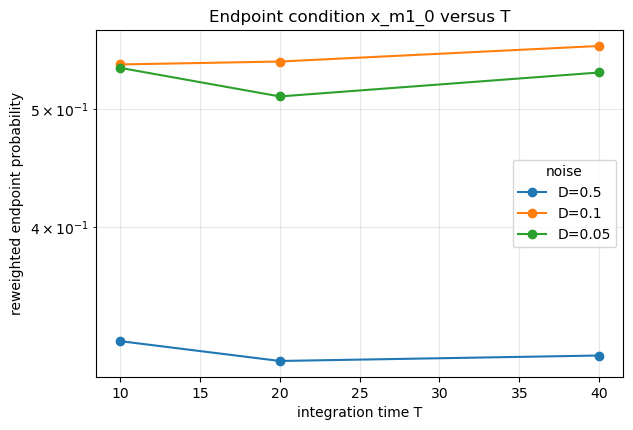

In [12]:
ENDPOINT_CONDITIONS = {
    "x_m1_0": lambda x: (x >= -1.0) & (x < 0.0),
    "x_gt0": lambda x: x > 0.0,
    "x_gt_0p5": lambda x: x > 0.5,
}

endpoint_prob_rows = []

for case_dir in case_dirs:
    _, T, D = case_metadata(case_dir)
    df = read_csv_if_exists(case_dir / "hist_endpoint_x_T.csv")
    if df is None or df.empty:
        continue

    needed = {"x_T_center", "unbiased_count"}
    if not needed.issubset(df.columns):
        print(f"Skipping {label_for_case(case_dir)}; missing {needed - set(df.columns)}")
        continue

    work = df[["x_T_center", "unbiased_count"]].copy()
    work["x_T_center"] = pd.to_numeric(work["x_T_center"], errors="coerce")
    work["unbiased_count"] = pd.to_numeric(work["unbiased_count"], errors="coerce")
    work = work.dropna()
    work = work[np.isfinite(work["x_T_center"]) & np.isfinite(work["unbiased_count"]) & (work["unbiased_count"] >= 0)]

    total = work["unbiased_count"].sum()
    if total <= 0:
        continue

    x = work["x_T_center"].to_numpy(dtype=float)
    w = work["unbiased_count"].to_numpy(dtype=float)

    for name, fn in ENDPOINT_CONDITIONS.items():
        prob = w[fn(x)].sum() / total
        endpoint_prob_rows.append({"T": T, "D": D, "condition": name, "probability": prob})

endpoint_prob_df = pd.DataFrame(endpoint_prob_rows)

if endpoint_prob_df.empty:
    print("No endpoint probability data found.")
else:
    display(endpoint_prob_df.sort_values(["condition", "D", "T"]))

    for condition in ["x_gt0", "x_gt_0p5", "x_m1_0"]:
        sub_cond = endpoint_prob_df[endpoint_prob_df["condition"] == condition]
        if sub_cond.empty:
            continue

        fig, ax = plt.subplots(figsize=(6.8, 4.5))
        for D, sub in sorted(sub_cond.groupby("D"), reverse=True):
            sub = sub.sort_values("T")
            ax.plot(sub["T"], sub["probability"], marker="o", label=f"D={D:g}")

        ax.set_xlabel("integration time T")
        ax.set_ylabel("reweighted endpoint probability")
        ax.set_title(f"Endpoint condition {condition} versus T")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(title="noise")
        save_and_maybe_show(fig, f"endpoint_probability_vs_T_{condition}.png")


## 5. Endpoint-probability heatmaps in the `(T, D)` grid

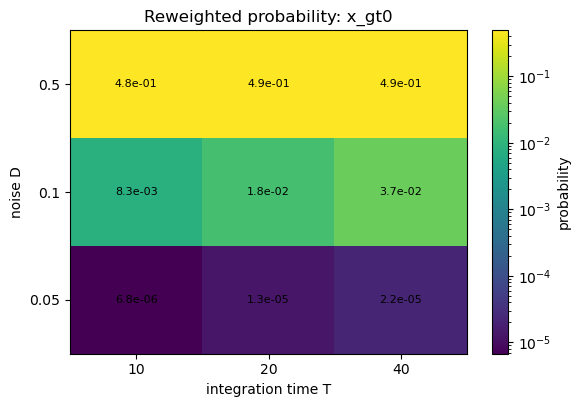

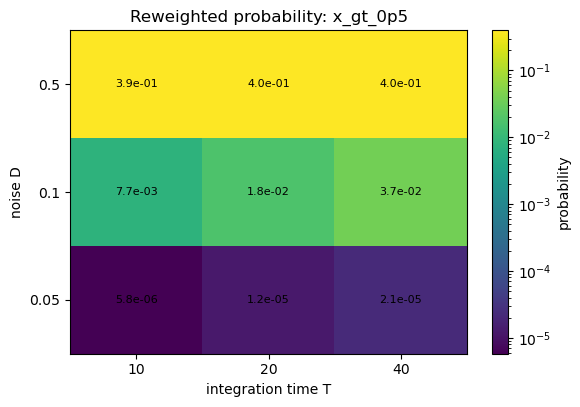

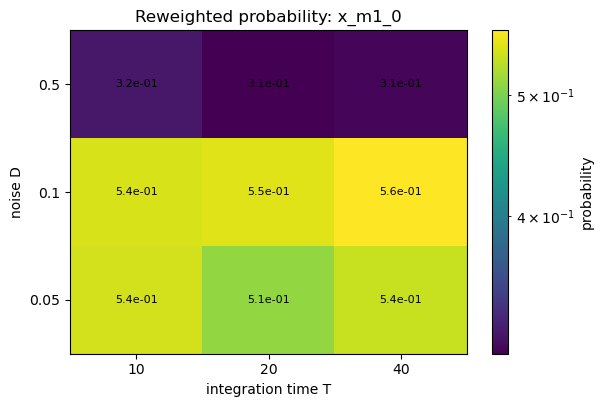

In [13]:
if endpoint_prob_df.empty:
    print("No endpoint probability data for heatmaps.")
else:
    for condition in ["x_gt0", "x_gt_0p5", "x_m1_0"]:
        sub = endpoint_prob_df[endpoint_prob_df["condition"] == condition].copy()
        if sub.empty:
            continue

        grid = sub.pivot_table(index="D", columns="T", values="probability", aggfunc="mean").sort_index(ascending=False).sort_index(axis=1)
        Z = grid.to_numpy(dtype=float)

        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        positive = Z[np.isfinite(Z) & (Z > 0)]
        if positive.size > 0:
            mesh = ax.imshow(
                Z,
                aspect="auto",
                origin="upper",
                norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
            )
        else:
            mesh = ax.imshow(Z, aspect="auto", origin="upper")

        ax.set_xticks(np.arange(len(grid.columns)))
        ax.set_xticklabels([f"{x:g}" for x in grid.columns])
        ax.set_yticks(np.arange(len(grid.index)))
        ax.set_yticklabels([f"{y:g}" for y in grid.index])
        ax.set_xlabel("integration time T")
        ax.set_ylabel("noise D")
        ax.set_title(f"Reweighted probability: {condition}")
        fig.colorbar(mesh, ax=ax, label="probability")

        for i, D in enumerate(grid.index):
            for j, T in enumerate(grid.columns):
                val = grid.loc[D, T]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.1e}", ha="center", va="center", fontsize=8)

        save_and_maybe_show(fig, f"endpoint_probability_heatmap_{condition}.png")


## 6. Endpoint PDFs across `T` for each noise

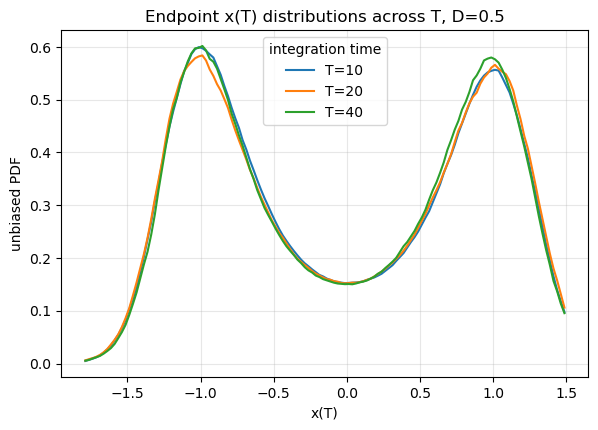

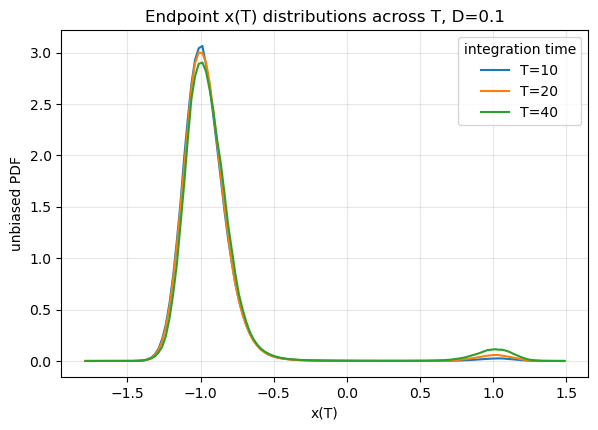

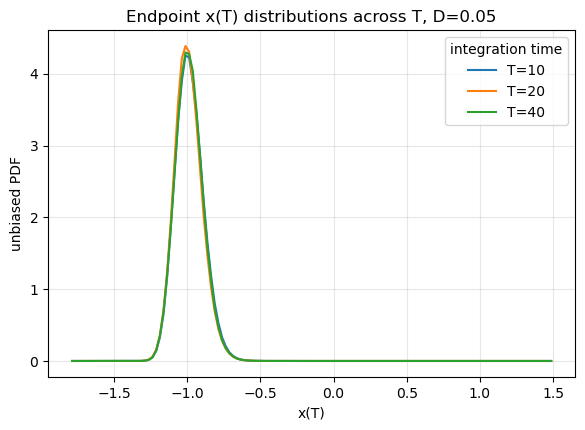

In [14]:
for D in sorted({case_metadata(p)[2] for p in case_dirs if np.isfinite(case_metadata(p)[2])}, reverse=True):
    fig, ax = plt.subplots(figsize=(6.8, 4.5))
    any_data = False

    for case_dir in case_dirs:
        _, T, DD = case_metadata(case_dir)
        if not np.isfinite(DD) or not np.isclose(D, DD):
            continue
        df = read_csv_if_exists(case_dir / "hist_endpoint_x_T.csv")
        if df is None or df.empty or not {"x_T_center", "unbiased_pdf"}.issubset(df.columns):
            continue
        df = df.copy()
        df["x_T_center"] = pd.to_numeric(df["x_T_center"], errors="coerce")
        df["unbiased_pdf"] = pd.to_numeric(df["unbiased_pdf"], errors="coerce")
        df = df.dropna().sort_values("x_T_center")
        ax.plot(df["x_T_center"], df["unbiased_pdf"], label=f"T={T:g}")
        any_data = True

    if any_data:
        ax.set_xlabel("x(T)")
        ax.set_ylabel("unbiased PDF")
        ax.set_title(f"Endpoint x(T) distributions across T, D={D:g}")
        ax.grid(True, alpha=0.3)
        ax.legend(title="integration time")
        save_and_maybe_show(fig, f"endpoint_xT_pdf_across_T_D{safe_name(D)}.png")
    else:
        plt.close(fig)


## 7. MUCA convergence and roundtrip diagnostics

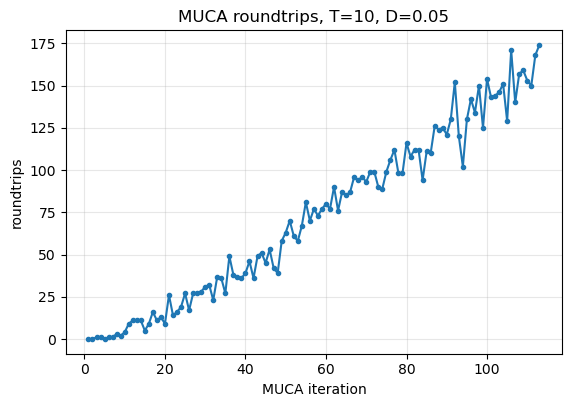

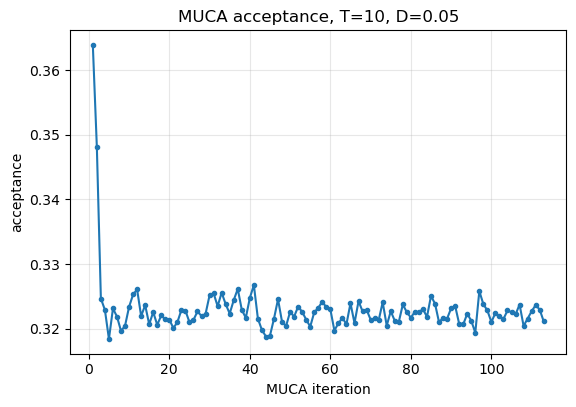

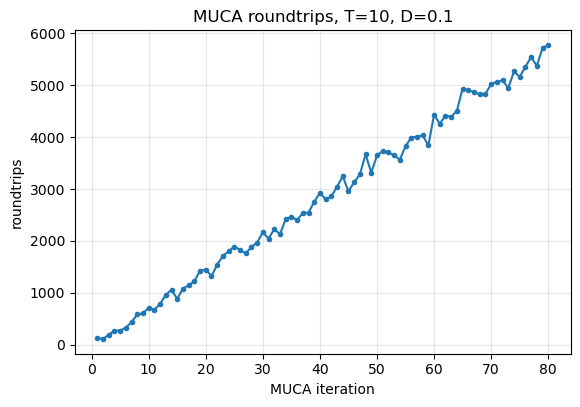

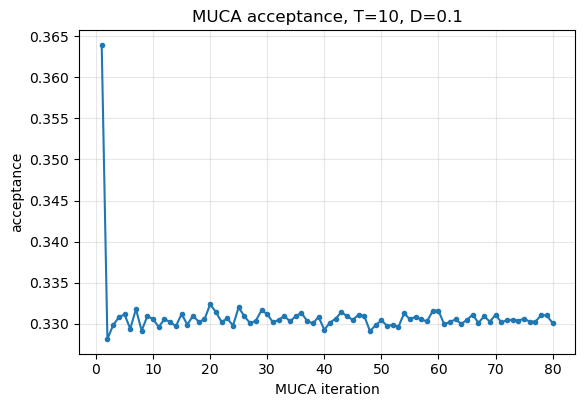

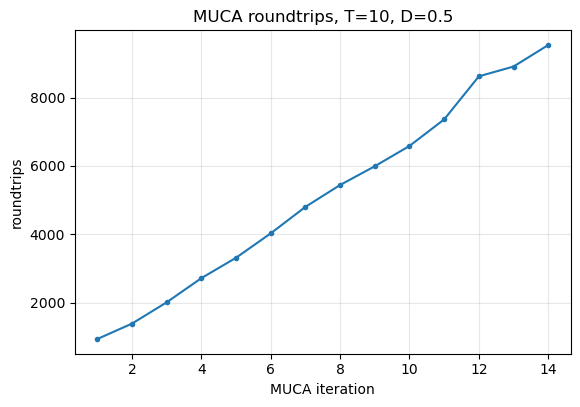

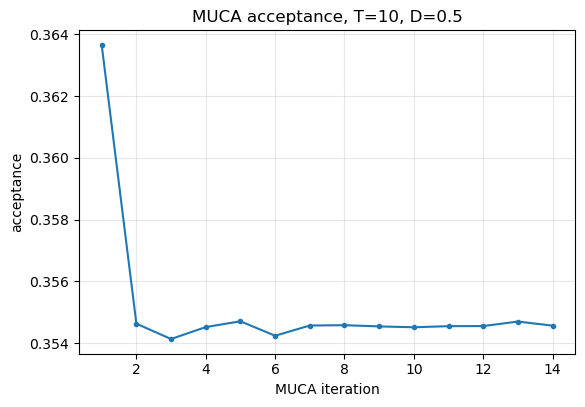

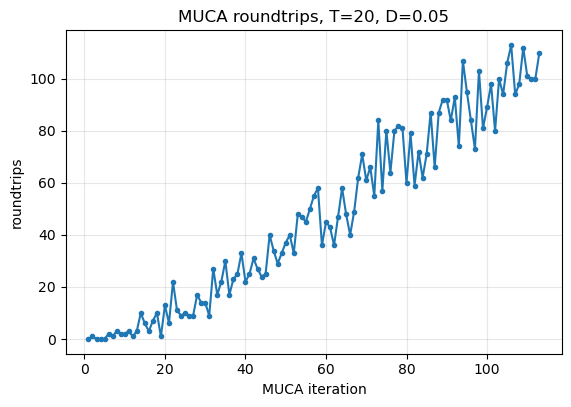

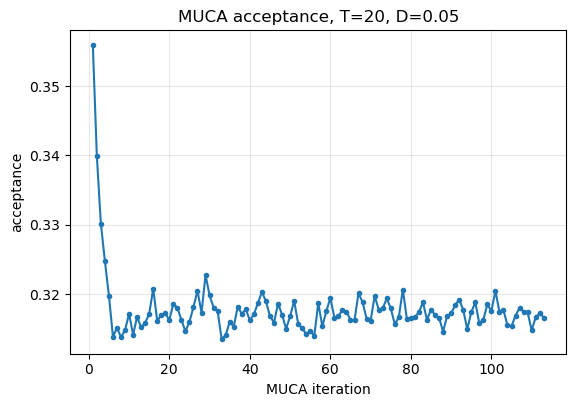

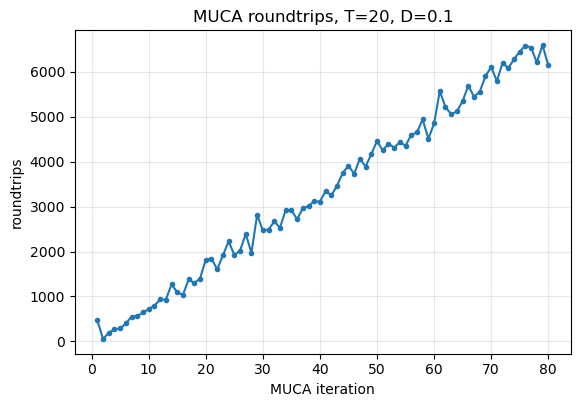

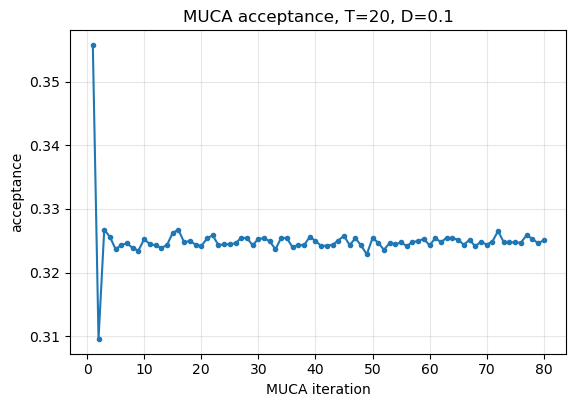

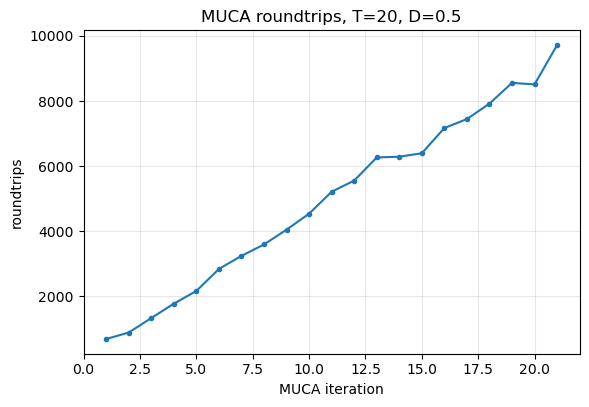

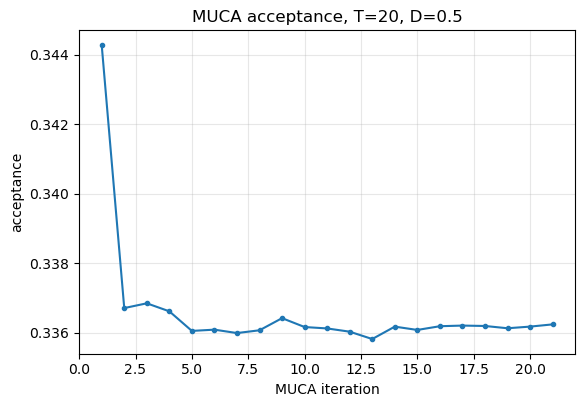

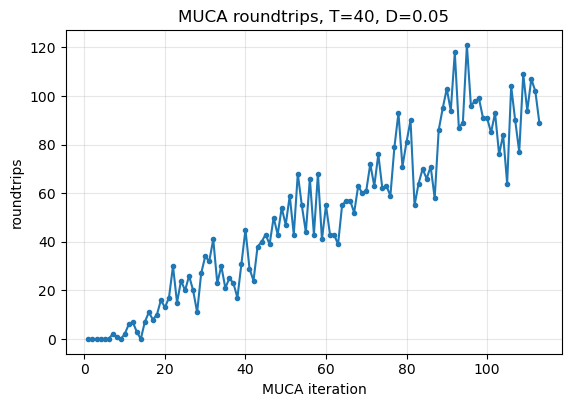

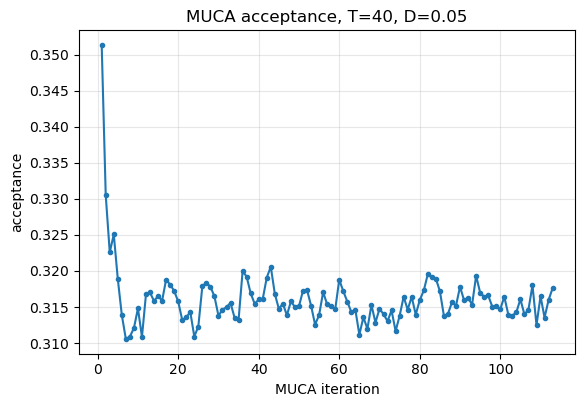

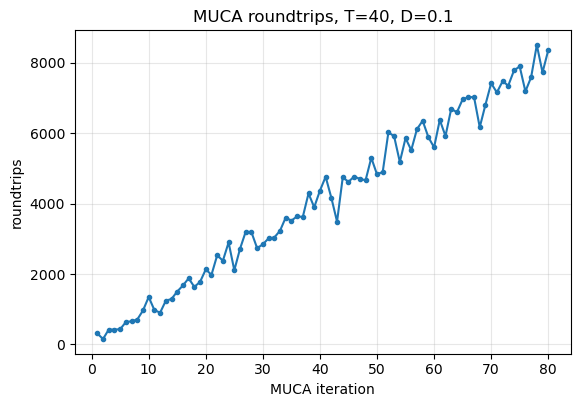

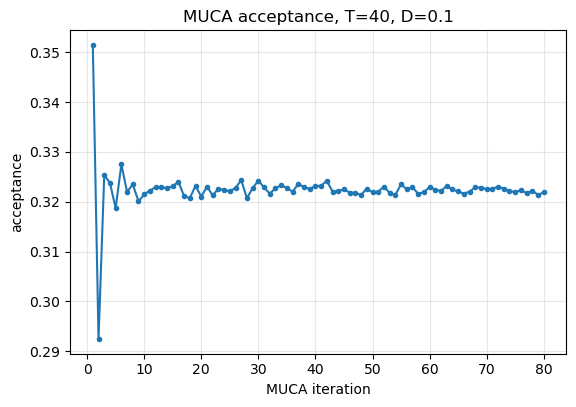

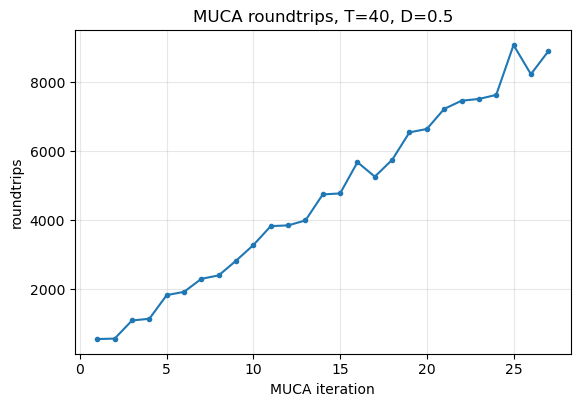

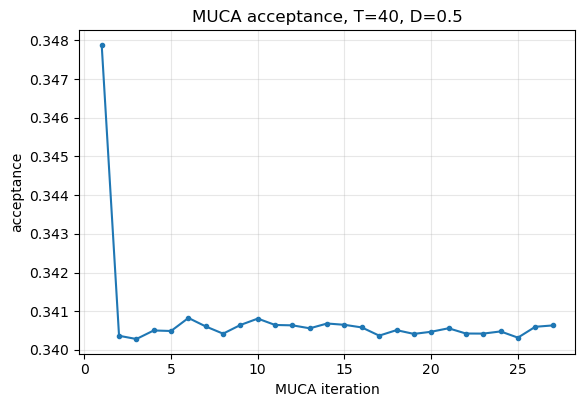

,T,D,final_iteration,final_roundtrips
2,10.0,0.50,14.0,9534.0
5,20.0,0.50,21.0,9719.0
8,40.0,0.50,27.0,8895.0
1,10.0,0.10,80.0,5776.0
4,20.0,0.10,80.0,6149.0
7,40.0,0.10,80.0,8360.0
0,10.0,0.05,113.0,174.0
3,20.0,0.05,113.0,110.0
6,40.0,0.05,113.0,89.0


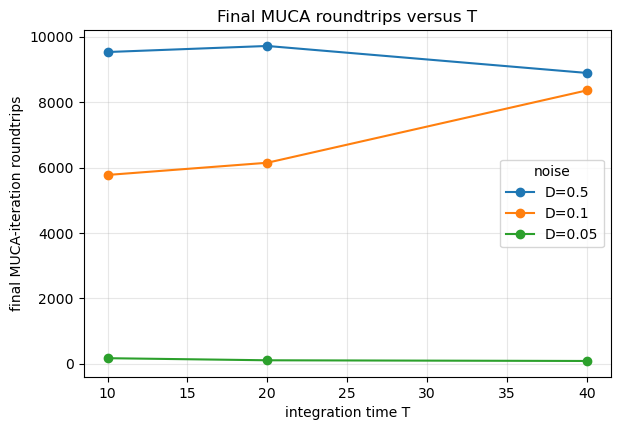

In [15]:
muca_final_rows = []

for case_dir in case_dirs:
    _, T, D = case_metadata(case_dir)
    diag = read_csv_if_exists(case_dir / "muca_iteration_diagnostics.csv")
    if diag is None or diag.empty:
        continue

    for col in diag.columns:
        diag[col] = pd.to_numeric(diag[col], errors="coerce")
    diag = diag.sort_values("iteration") if "iteration" in diag.columns else diag

    label = label_for_case(case_dir)
    tag = case_tag(case_dir)

    if {"iteration", "roundtrips"}.issubset(diag.columns):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(diag["iteration"], diag["roundtrips"], marker=".")
        ax.set_xlabel("MUCA iteration")
        ax.set_ylabel("roundtrips")
        ax.set_title(f"MUCA roundtrips, {label}")
        ax.grid(True, alpha=0.3)
        save_and_maybe_show(fig, f"{tag}_muca_roundtrips.png")

    if {"iteration", "acceptance"}.issubset(diag.columns):
        fig, ax = plt.subplots(figsize=(6.4, 4.2))
        ax.plot(diag["iteration"], diag["acceptance"], marker=".")
        ax.set_xlabel("MUCA iteration")
        ax.set_ylabel("acceptance")
        ax.set_title(f"MUCA acceptance, {label}")
        ax.grid(True, alpha=0.3)
        save_and_maybe_show(fig, f"{tag}_muca_acceptance.png")

    if {"iteration", "roundtrips"}.issubset(diag.columns):
        final = diag.dropna(subset=["iteration", "roundtrips"]).tail(1)
        if not final.empty:
            muca_final_rows.append({
                "T": T,
                "D": D,
                "final_iteration": float(final["iteration"].iloc[0]),
                "final_roundtrips": float(final["roundtrips"].iloc[0]),
            })

muca_final_df = pd.DataFrame(muca_final_rows)
if not muca_final_df.empty:
    display(muca_final_df.sort_values(["D", "T"], ascending=[False, True]))

    fig, ax = plt.subplots(figsize=(6.8, 4.5))
    for D, sub in sorted(muca_final_df.groupby("D"), reverse=True):
        sub = sub.sort_values("T")
        ax.plot(sub["T"], sub["final_roundtrips"], marker="o", label=f"D={D:g}")
    ax.set_xlabel("integration time T")
    ax.set_ylabel("final MUCA-iteration roundtrips")
    ax.set_title("Final MUCA roundtrips versus T")
    ax.grid(True, alpha=0.3)
    ax.legend(title="noise")
    save_and_maybe_show(fig, "final_muca_roundtrips_vs_T.png")


## 8. Production roundtrips

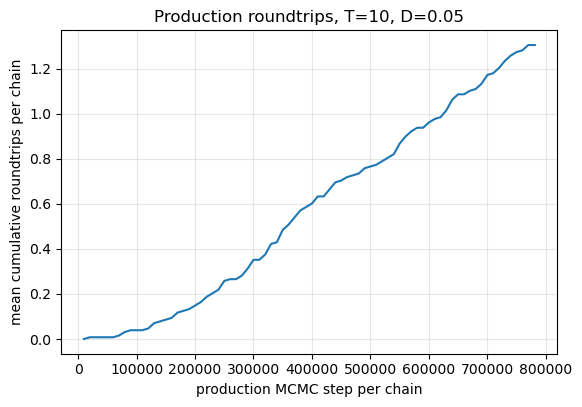

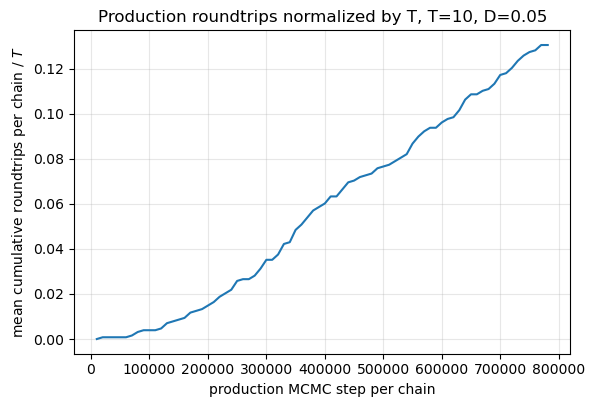

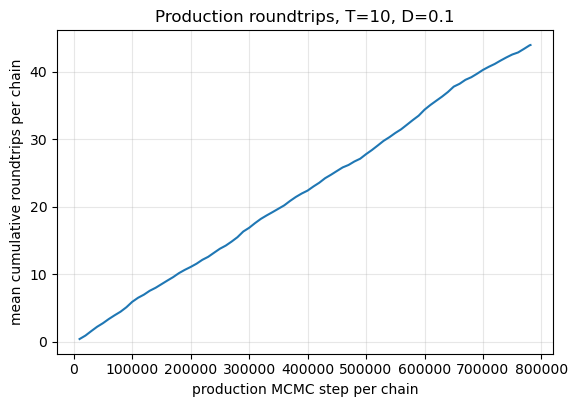

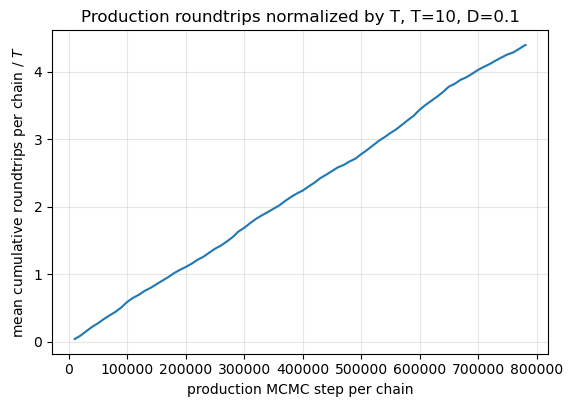

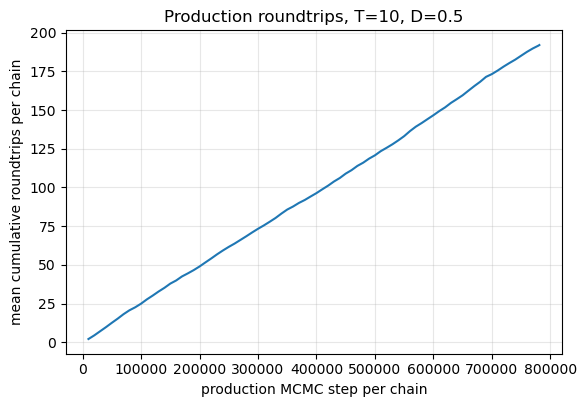

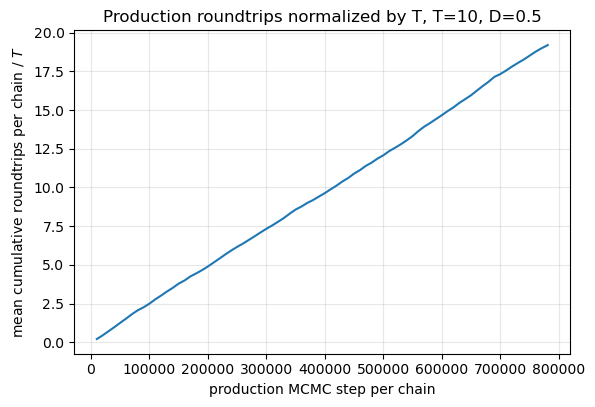

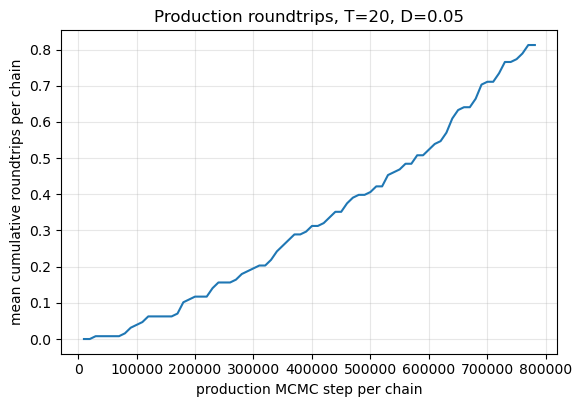

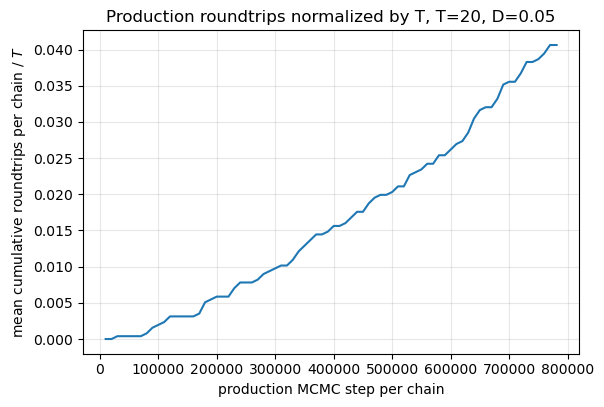

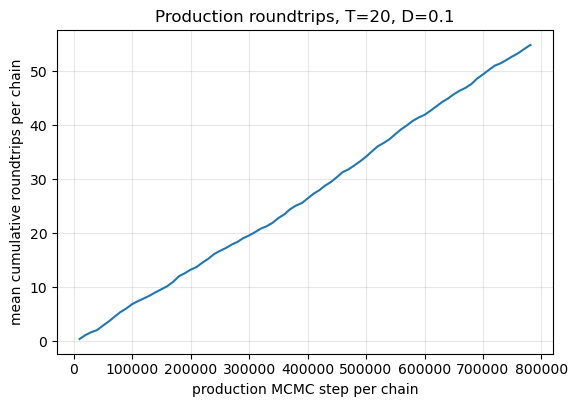

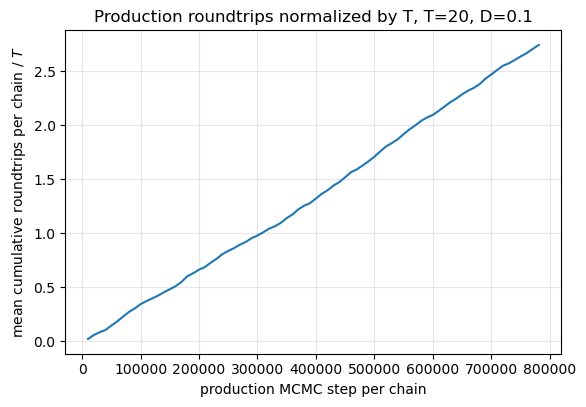

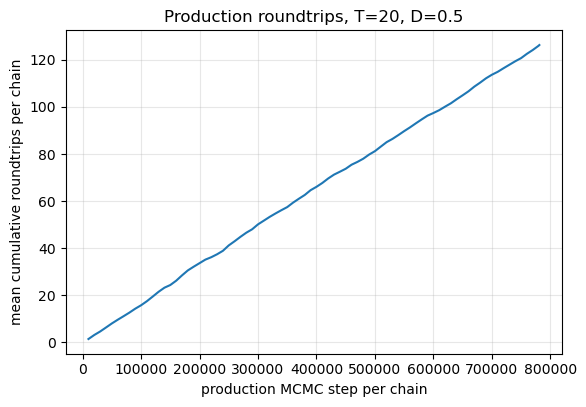

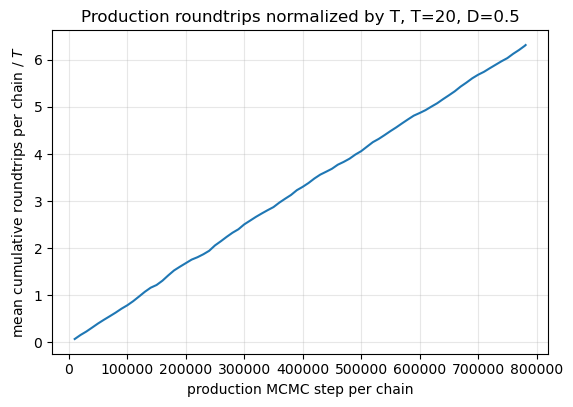

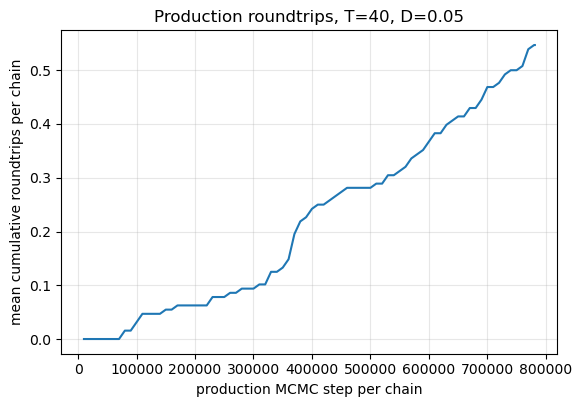

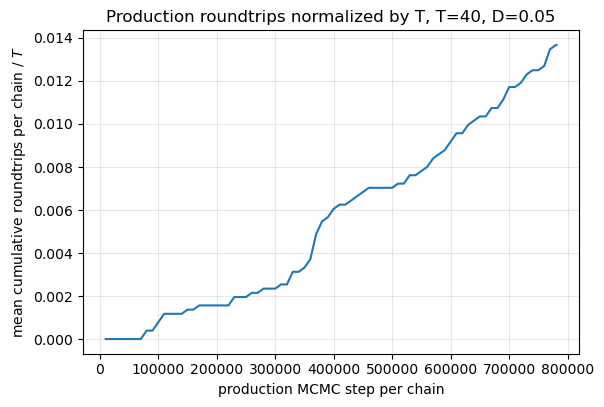

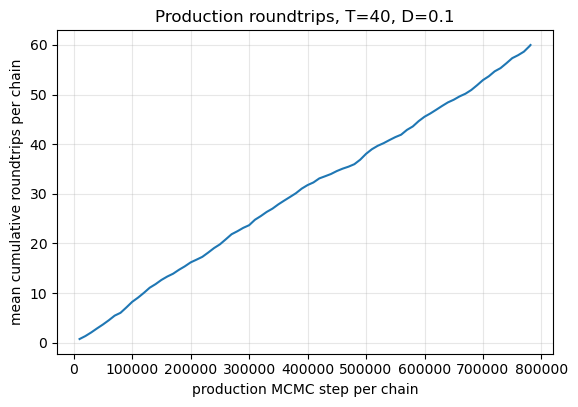

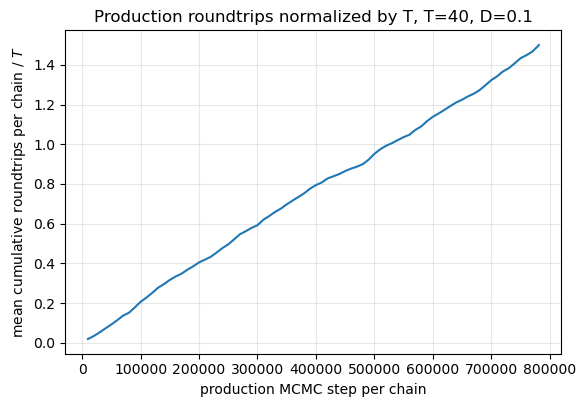

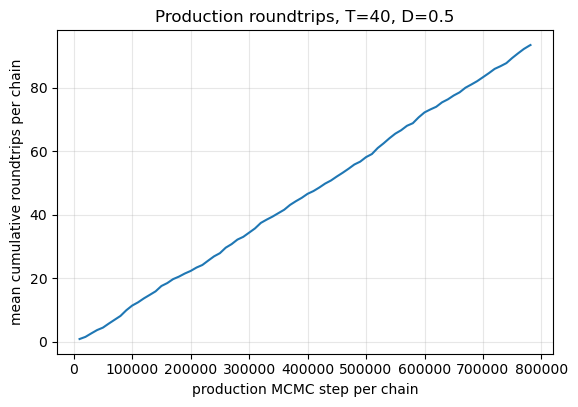

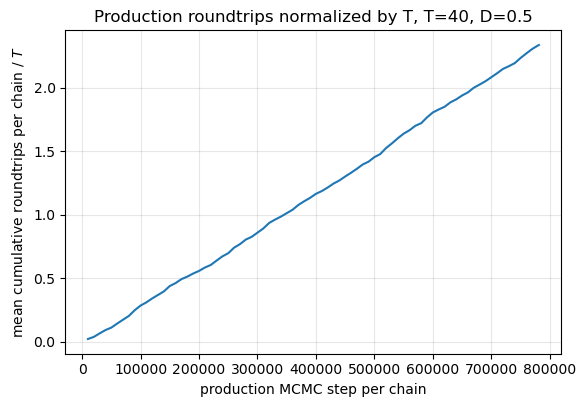

,T,D,final_step,final_mean_roundtrips_per_chain,final_mean_roundtrips_per_chain_over_T
2,10.0,0.50,781250.0,192.039062,19.203906
5,20.0,0.50,781250.0,126.304688,6.315234
8,40.0,0.50,781250.0,93.546875,2.338672
1,10.0,0.10,781250.0,43.929688,4.392969
4,20.0,0.10,781250.0,54.820312,2.741016
7,40.0,0.10,781250.0,59.992188,1.499805
0,10.0,0.05,781250.0,1.304688,0.130469
3,20.0,0.05,781250.0,0.812500,0.040625
6,40.0,0.05,781250.0,0.546875,0.013672


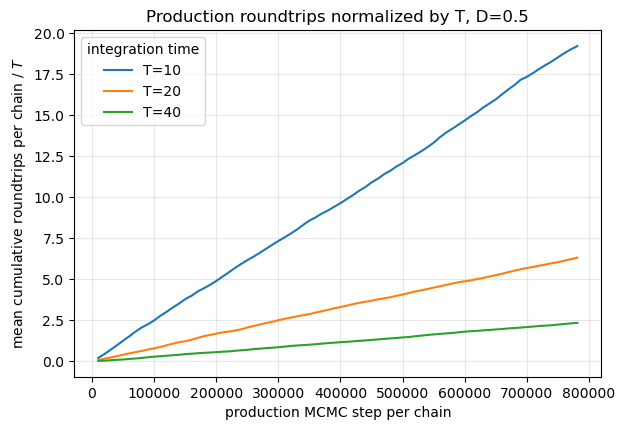

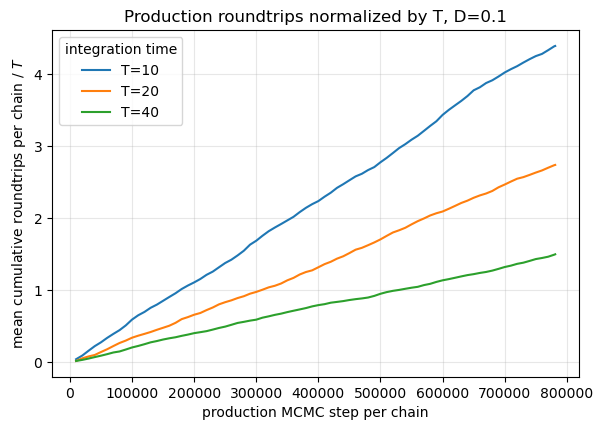

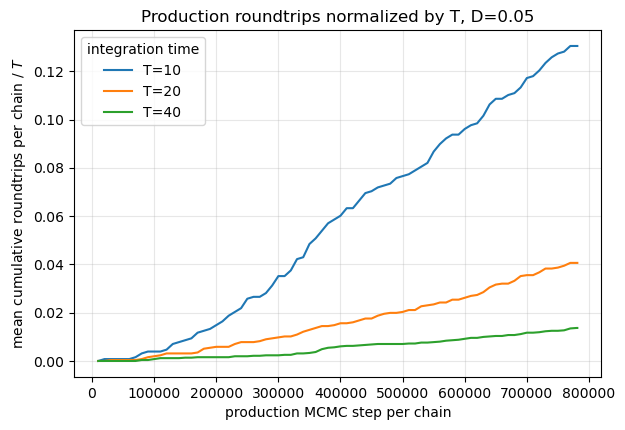

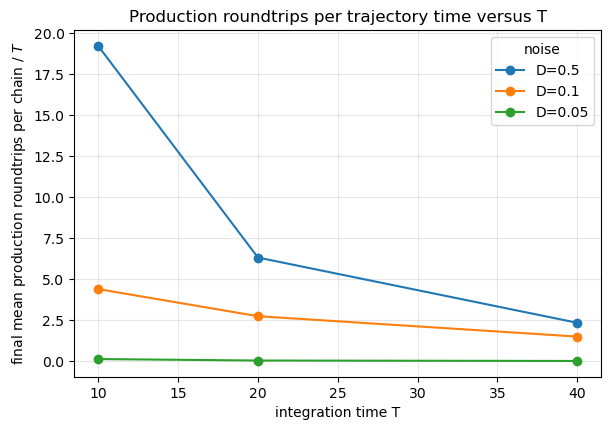

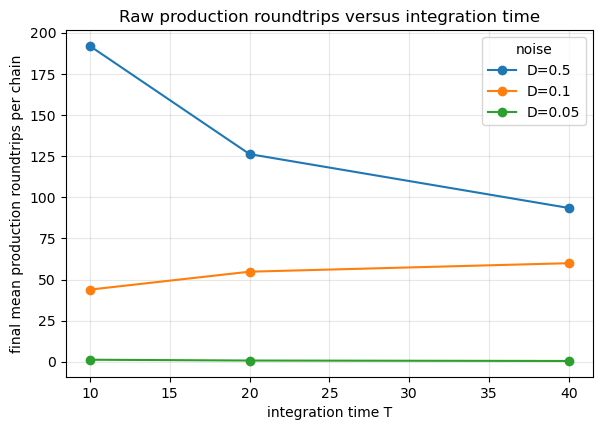

In [16]:
prod_rt_rows = []
prod_rt_curves = []

RT_RAW_COL = "mean_roundtrips_per_chain"
RT_NORM_COL = "mean_roundtrips_per_chain_over_T"

for case_dir in case_dirs:
    _, T, D = case_metadata(case_dir)

    df = read_csv_if_exists(case_dir / "production_roundtrip_aggregate.csv")
    if df is None or df.empty:
        print(f"No production_roundtrip_aggregate.csv for {label_for_case(case_dir)}")
        continue

    needed = {"local_step", "mean_roundtrips_per_chain"}
    if not needed.issubset(df.columns):
        print(f"Skipping {label_for_case(case_dir)}; missing {needed - set(df.columns)}")
        continue

    df = df.copy()
    df["local_step"] = pd.to_numeric(df["local_step"], errors="coerce")
    df["mean_roundtrips_per_chain"] = pd.to_numeric(
        df["mean_roundtrips_per_chain"],
        errors="coerce",
    )

    if "chains_reporting" in df.columns:
        df["chains_reporting"] = pd.to_numeric(df["chains_reporting"], errors="coerce")

    df = df.dropna(subset=["local_step", "mean_roundtrips_per_chain"]).sort_values("local_step")

    if df.empty:
        continue

    label = label_for_case(case_dir)
    tag = case_tag(case_dir)

    # ------------------------------------------------------------
    # Normalize roundtrips by physical integration time T.
    # This makes curves more comparable across different trajectory
    # durations T.
    # ------------------------------------------------------------

    if np.isfinite(T) and T > 0:
        df[RT_NORM_COL] = df[RT_RAW_COL] / T
    else:
        print(f"Warning: invalid T={T} for {label}; normalized roundtrips set to NaN.")
        df[RT_NORM_COL] = np.nan

    # ------------------------------------------------------------
    # Individual case plot: raw roundtrips
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.plot(df["local_step"], df[RT_RAW_COL])
    ax.set_xlabel("production MCMC step per chain")
    ax.set_ylabel("mean cumulative roundtrips per chain")
    ax.set_title(f"Production roundtrips, {label}")
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, f"{tag}_production_roundtrips_raw.png")

    # ------------------------------------------------------------
    # Individual case plot: roundtrips divided by T
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.plot(df["local_step"], df[RT_NORM_COL])
    ax.set_xlabel("production MCMC step per chain")
    ax.set_ylabel(r"mean cumulative roundtrips per chain / $T$")
    ax.set_title(f"Production roundtrips normalized by T, {label}")
    ax.grid(True, alpha=0.3)
    save_and_maybe_show(fig, f"{tag}_production_roundtrips_over_T.png")

    prod_rt_curves.append({
        "T": T,
        "D": D,
        "df": df,
        "label": label,
    })

    prod_rt_rows.append({
        "T": T,
        "D": D,
        "final_step": float(df["local_step"].iloc[-1]),
        "final_mean_roundtrips_per_chain": float(df[RT_RAW_COL].iloc[-1]),
        "final_mean_roundtrips_per_chain_over_T": float(df[RT_NORM_COL].iloc[-1]),
    })


prod_rt_summary_df = pd.DataFrame(prod_rt_rows)

if not prod_rt_summary_df.empty:
    display(prod_rt_summary_df.sort_values(["D", "T"], ascending=[False, True]))

    # ============================================================
    # Overlay across T for each D: normalized by T
    # ============================================================

    for D in sorted(prod_rt_summary_df["D"].dropna().unique(), reverse=True):
        fig, ax = plt.subplots(figsize=(6.8, 4.5))
        any_data = False

        for row in prod_rt_curves:
            if not np.isclose(row["D"], D):
                continue

            df = row["df"]
            ax.plot(
                df["local_step"],
                df[RT_NORM_COL],
                label=f"T={row['T']:g}",
            )
            any_data = True

        if any_data:
            ax.set_xlabel("production MCMC step per chain")
            ax.set_ylabel(r"mean cumulative roundtrips per chain / $T$")
            ax.set_title(f"Production roundtrips normalized by T, D={D:g}")
            ax.grid(True, alpha=0.3)
            ax.legend(title="integration time")
            save_and_maybe_show(fig, f"production_roundtrips_over_T_across_T_D{safe_name(D)}.png")
        else:
            plt.close(fig)

    # ============================================================
    # Final normalized production RT versus T
    # ============================================================

    fig, ax = plt.subplots(figsize=(6.8, 4.5))

    for D, sub in sorted(prod_rt_summary_df.groupby("D"), reverse=True):
        sub = sub.sort_values("T")
        ax.plot(
            sub["T"],
            sub["final_mean_roundtrips_per_chain_over_T"],
            marker="o",
            label=f"D={D:g}",
        )

    ax.set_xlabel("integration time T")
    ax.set_ylabel(r"final mean production roundtrips per chain / $T$")
    ax.set_title("Production roundtrips per trajectory time versus T")
    ax.grid(True, alpha=0.3)
    ax.legend(title="noise")
    save_and_maybe_show(fig, "final_production_roundtrips_over_T_vs_T.png")

    # ============================================================
    # Optional: keep raw final roundtrips versus T too
    # ============================================================

    fig, ax = plt.subplots(figsize=(6.8, 4.5))

    for D, sub in sorted(prod_rt_summary_df.groupby("D"), reverse=True):
        sub = sub.sort_values("T")
        ax.plot(
            sub["T"],
            sub["final_mean_roundtrips_per_chain"],
            marker="o",
            label=f"D={D:g}",
        )

    ax.set_xlabel("integration time T")
    ax.set_ylabel("final mean production roundtrips per chain")
    ax.set_title("Raw production roundtrips versus integration time")
    ax.grid(True, alpha=0.3)
    ax.legend(title="noise")
    save_and_maybe_show(fig, "final_production_roundtrips_raw_vs_T.png")

## 9. Conditional path heatmap and `x(t)≈0` cut, selected cases

This reuses the path-window CSVs from the patched code. It produces one compact diagnostic for `x(T)>0.5`.

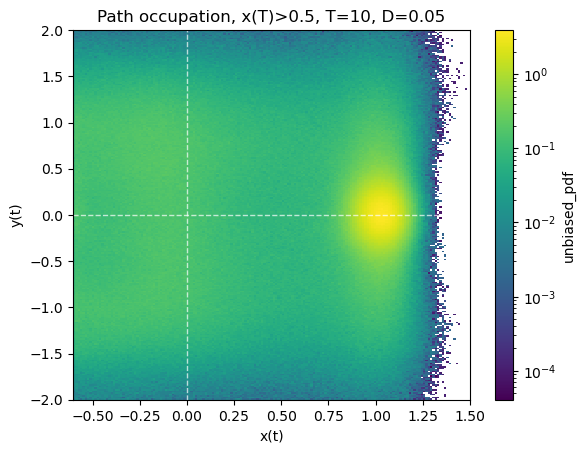

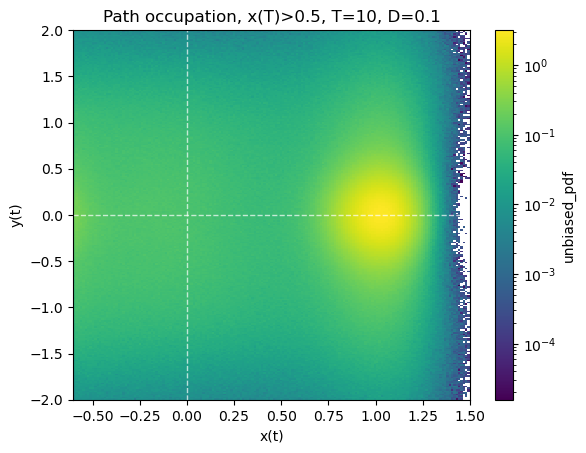

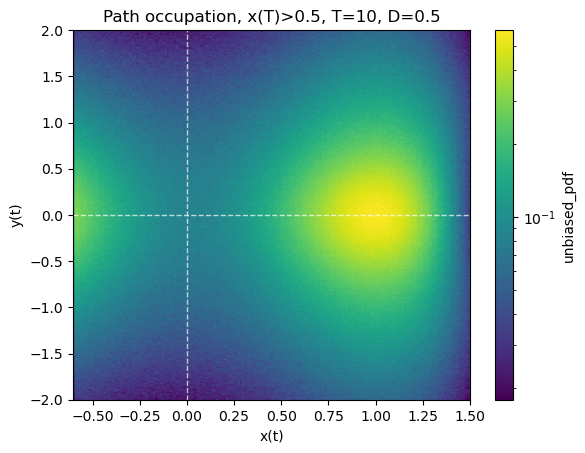

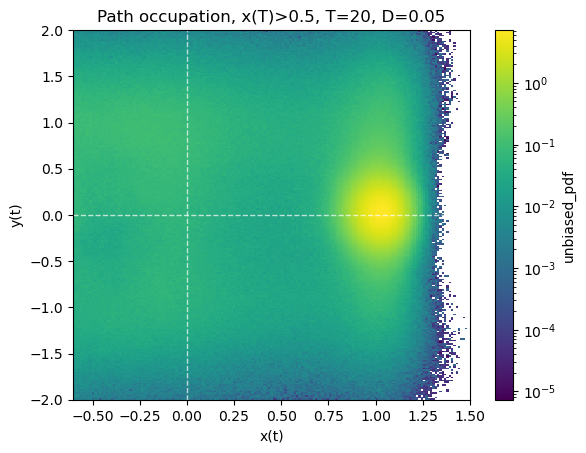

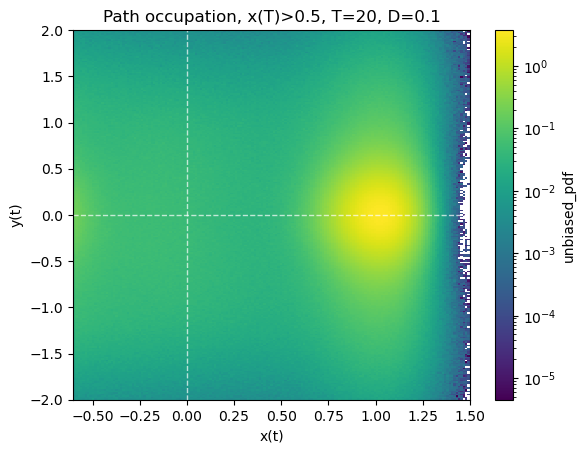

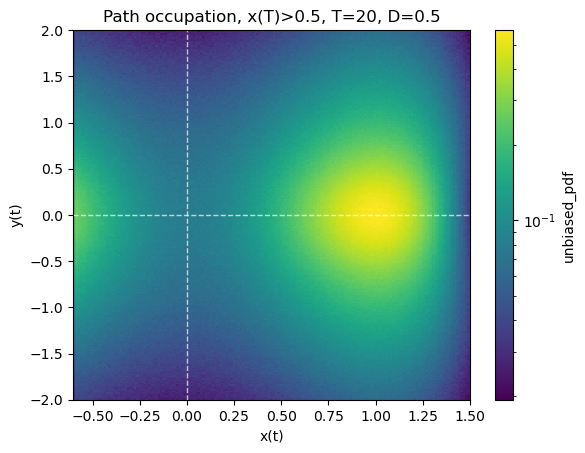

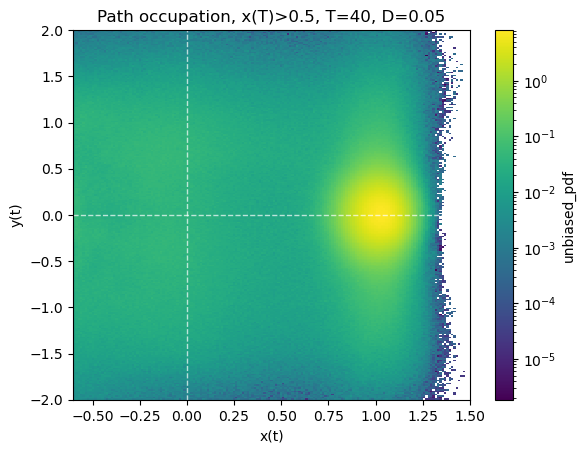

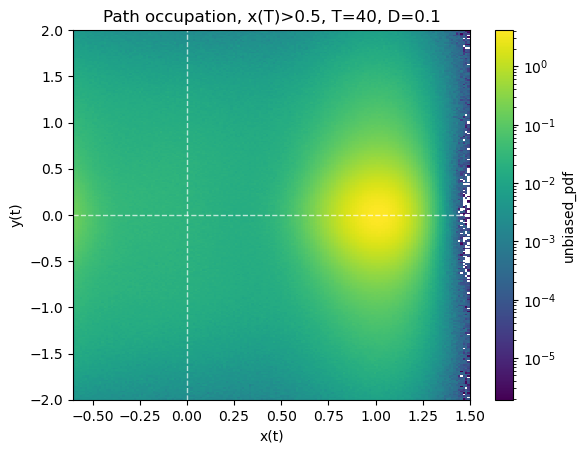

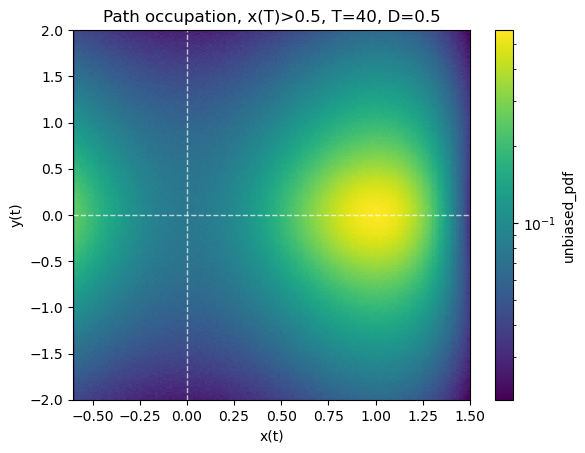

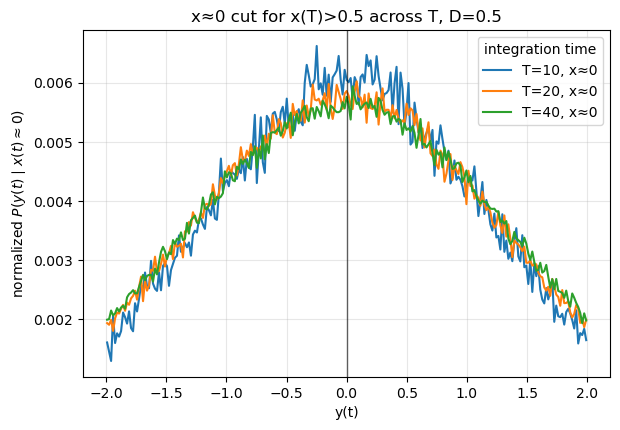

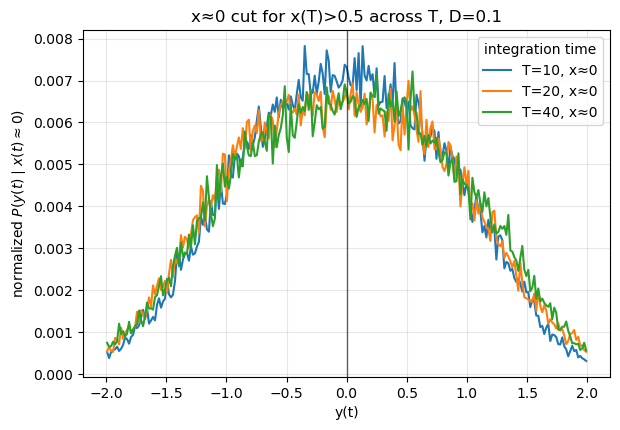

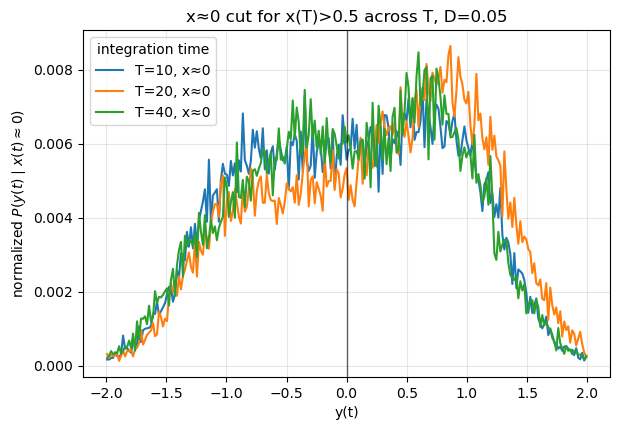

In [17]:
PATH_FILE = "endpoint_x_gt_0p5_filtered_path_x_y_long.csv"
PATH_VALUE_COL = "unbiased_pdf"
XCUT_VALUE_COL = "unbiased_count"
PATH_X_DISPLAY_RANGE = (-0.6, 1.5)
PATH_Y_DISPLAY_RANGE = (-2.0, 2.0)
XCUT_TARGET = 0.0


def centers_to_edges(c):
    c = np.asarray(sorted(np.unique(c)), dtype=float)
    if len(c) < 2:
        d = 0.5
        return np.array([c[0] - d, c[0] + d])
    mids = 0.5 * (c[:-1] + c[1:])
    return np.r_[c[0] - (mids[0] - c[0]), mids, c[-1] + (c[-1] - mids[-1])]


def prepare_path_grid(df, value_col, x_range=None, y_range=None):
    needed = {"path_x_center", "path_y_center", value_col}
    if df is None or df.empty or not needed.issubset(df.columns):
        return None
    work = df[["path_x_center", "path_y_center", value_col]].copy()
    for col in work.columns:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work = work.dropna()
    work = restrict_range(work, "path_x_center", x_range)
    work = restrict_range(work, "path_y_center", y_range)
    if work.empty:
        return None
    return (
        work.pivot_table(index="path_y_center", columns="path_x_center", values=value_col, aggfunc="sum", fill_value=0.0)
        .sort_index()
        .sort_index(axis=1)
    )


def extract_y_cut_at_x(grid, x_target=0.0):
    if grid is None or grid.empty:
        return None
    x_centers = grid.columns.to_numpy(dtype=float)
    y_centers = grid.index.to_numpy(dtype=float)
    j = int(np.argmin(np.abs(x_centers - x_target)))
    weights = grid.iloc[:, j].to_numpy(dtype=float)
    total = np.nansum(weights)
    return pd.DataFrame({
        "y": y_centers,
        "profile": weights / total if total > 0 else weights * np.nan,
        "x_repr": float(x_centers[j]),
    })


# Heatmaps for all completed cases.
cut_rows = []
for case_dir in case_dirs:
    _, T, D = case_metadata(case_dir)
    df = read_csv_if_exists(case_dir / PATH_FILE)
    if df is None or df.empty:
        continue

    heat_grid = prepare_path_grid(df, PATH_VALUE_COL, PATH_X_DISPLAY_RANGE, PATH_Y_DISPLAY_RANGE)
    cut_grid = prepare_path_grid(df, XCUT_VALUE_COL, PATH_X_DISPLAY_RANGE, PATH_Y_DISPLAY_RANGE)
    if heat_grid is None or cut_grid is None:
        continue

    x = heat_grid.columns.to_numpy(dtype=float)
    y = heat_grid.index.to_numpy(dtype=float)
    Z = heat_grid.to_numpy(dtype=float)
    positive = Z[np.isfinite(Z) & (Z > 0)]
    if positive.size > 0:
        fig, ax = plt.subplots(figsize=(6.4, 4.8))
        mesh = ax.pcolormesh(
            centers_to_edges(x),
            centers_to_edges(y),
            Z,
            shading="auto",
            norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
        )
        fig.colorbar(mesh, ax=ax, label=PATH_VALUE_COL)
        ax.axvline(0.0, color="white", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.axhline(0.0, color="white", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.set_xlabel("x(t)")
        ax.set_ylabel("y(t)")
        ax.set_title(f"Path occupation, x(T)>0.5, T={T:g}, D={D:g}")
        save_and_maybe_show(fig, f"path_xy_x_gt_0p5_T{safe_name(T)}_D{safe_name(D)}.png")

    cut = extract_y_cut_at_x(cut_grid, XCUT_TARGET)
    if cut is not None and not cut.empty:
        cut_rows.append({"T": T, "D": D, "x_repr": float(cut["x_repr"].iloc[0]), "cut": cut})

# Overlay cuts across T for each D.
for D in sorted({r["D"] for r in cut_rows if np.isfinite(r["D"])}, reverse=True):
    fig, ax = plt.subplots(figsize=(6.8, 4.5))
    any_data = False
    for r in sorted([r for r in cut_rows if np.isclose(r["D"], D)], key=lambda r: r["T"]):
        cut = r["cut"]
        ax.plot(cut["y"], cut["profile"], label=f"T={r['T']:g}, x≈{r['x_repr']:.3g}")
        any_data = True
    if any_data:
        ax.axvline(0.0, color="black", linewidth=1.0, alpha=0.6)
        ax.set_xlabel("y(t)")
        ax.set_ylabel(r"normalized $P(y(t) \mid x(t)\approx0)$")
        ax.set_title(f"x≈0 cut for x(T)>0.5 across T, D={D:g}")
        ax.grid(True, alpha=0.3)
        ax.legend(title="integration time")
        save_and_maybe_show(fig, f"x0_y_cut_x_gt_0p5_across_T_D{safe_name(D)}.png")
    else:
        plt.close(fig)


## 10. Saved figure list